##### Inteligencia Articial II - UDEM
###### 5 de Marzo de 2026
###### Docente: Andres Hernandez Gutierrez
#### Mauricio Gonzalez Valero 594595, Roberto Sandoval 598270

## 1. Introduction to the real world problem and dataset

**Dataset:** Diabetes Dataset (clasificación binaria). Este

**Objetivo:** predecir si un paciente tiene diabetes.

**Variables predictoras:** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.

**Variable objetivo:** Outcome (
0 = no diabetes,
1 = diabetes )


**Descripción General:** Este dataset tiene datos médicos de pacientes femeninos de origen Pima Indian, y estos datos se usan para predecir si una persona tiene o no diabetes. El problema es de clasificación binaria, y la variable objetivo dirá si el paciente es diagnosticado con diabetes. Las variables que se encuentran son:
*   Pregnancies – número de embarazos
*   Glucose – nivel de glucosa en la sangre
*   BloodPressure – presión arterial
*   SkinThickness – grosor de la piel
*   Insulin – nivel de insulina
*   BMI – índice de masa corporal
*   DiabetesPedigreeFunction – historial familiar de diabetes
*   Age – edad del paciente
*   Outcome – variable objetivo (0 = no diabetes, 1 = diabetes)

https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset


En esta actividad se va a analizar un dataset de diabetes para predecir si un paciente tiene o no esta enfermedad. Se va a realizar un análisis de los datos para entender sus características, y después de eso se entrena un modelo de clasificaciones usando una sola neurona como función de activación sigmoid. Luego se va a aplicar PCA en el modelo para reducir la dimensionalidad del dataset y se va a entrenar otra vez el modelo usando ahora las nuevas variables generadas por PCA. Y finalmente se van a comparar ambos modelos.

En las siguientes celdas de código se cargará el dataset que se usará para el análisis y el entrenamiento del modelo. Se revisará la estructura general del dataset para ver cuántas observaciones y variables tiene. También se mostrarán estadísticas básicas para tener idea de la distribución de las variables. También se revisará si existen valores de cero en algunas variables que podrían representar datos faltantes.

En la siguiente celda de código se cargará el dataset y haremos la exploración inicial.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report

df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
display(df.head())

display(df.info())
display(df.describe())

cols_cero_invalido = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nConteo de ceros (posibles faltantes):")
display((df[cols_cero_invalido] == 0).sum().to_frame("zeros"))


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Conteo de ceros (posibles faltantes):


,zeros
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


Los resultados anteriores permiten observar la estructura general del dataset, incluyendo el número de observaciones, las variables disponibles y algunas estadísticas básicas.

También se identificaron valores iguales a cero en algunas variables médicas como Glucose, BloodPressure, SkinThickness, Insulin y BMI. En este tipo de dataset, estos valores normalmente no representan mediciones reales, por lo que pueden interpretarse como valores faltantes.

Antes de continuar con el análisis exploratorio de datos, es necesario tratar estos valores para evitar que afecten los resultados del modelo.

En la siguiente celda se reemplazarán estos valores por NaN y se imputarán usando la mediana de cada variable.

In [ ]:
df_clean = df.copy()

cols_cero_invalido = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean[cols_cero_invalido] = df_clean[cols_cero_invalido].replace(0, np.nan)

df_clean = df_clean.fillna(df_clean.median())

print("Valores faltantes después de la imputación:")
display(df_clean.isna().sum())

Valores faltantes después de la imputación:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


En la celda anterior se realizó una limpieza básica del dataset. Los valores iguales a cero en algunas variables médicas se reemplazaron por valores faltantes y posteriormente se imputaron utilizando la mediana de cada variable.

Este procedimiento permite mantener la estructura del dataset sin eliminar observaciones completas y evita introducir valores extremos que podrían afectar el entrenamiento del modelo.

Ahora que los datos están limpios, se puede continuar con el análisis exploratorio para entender mejor la relación entre las variables.

En la siguiente celda se calculará la matriz de correlación para observar posibles relaciones entre las variables del dataset.

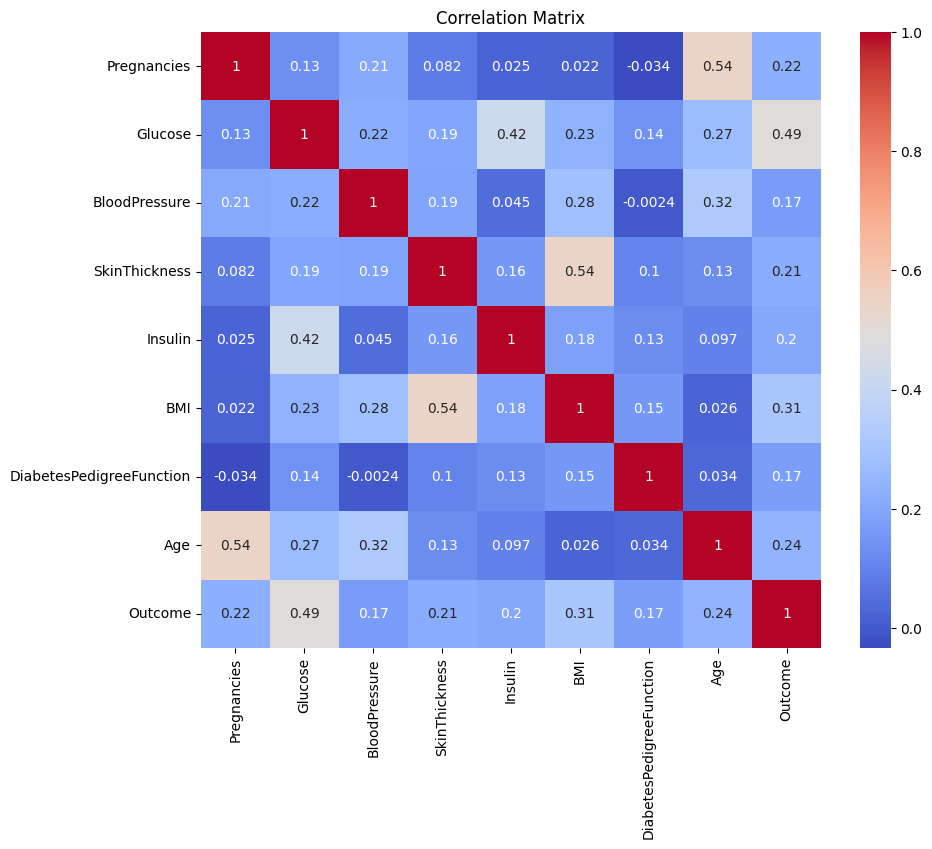

In [ ]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

La matriz de correlación permite observar la relación entre las diferentes variables del dataset.

Se pueden observar algunas correlaciones moderadas entre ciertas variables. Por ejemplo, **Glucose** muestra una correlación positiva con la variable **Outcome**, lo que sugiere que niveles más altos de glucosa pueden estar asociados con la presencia de diabetes.

También se puede observar cierta relación entre variables como **Age** y **Pregnancies**, lo cual tiene sentido ya que pacientes de mayor edad podrían haber tenido más embarazos.

En general, la mayoría de las variables presentan correlaciones moderadas o bajas entre sí, lo cual es común en datasets médicos.

En la siguiente celda se analizará la distribución de algunas variables del dataset para comprender mejor cómo se comportan los datos.

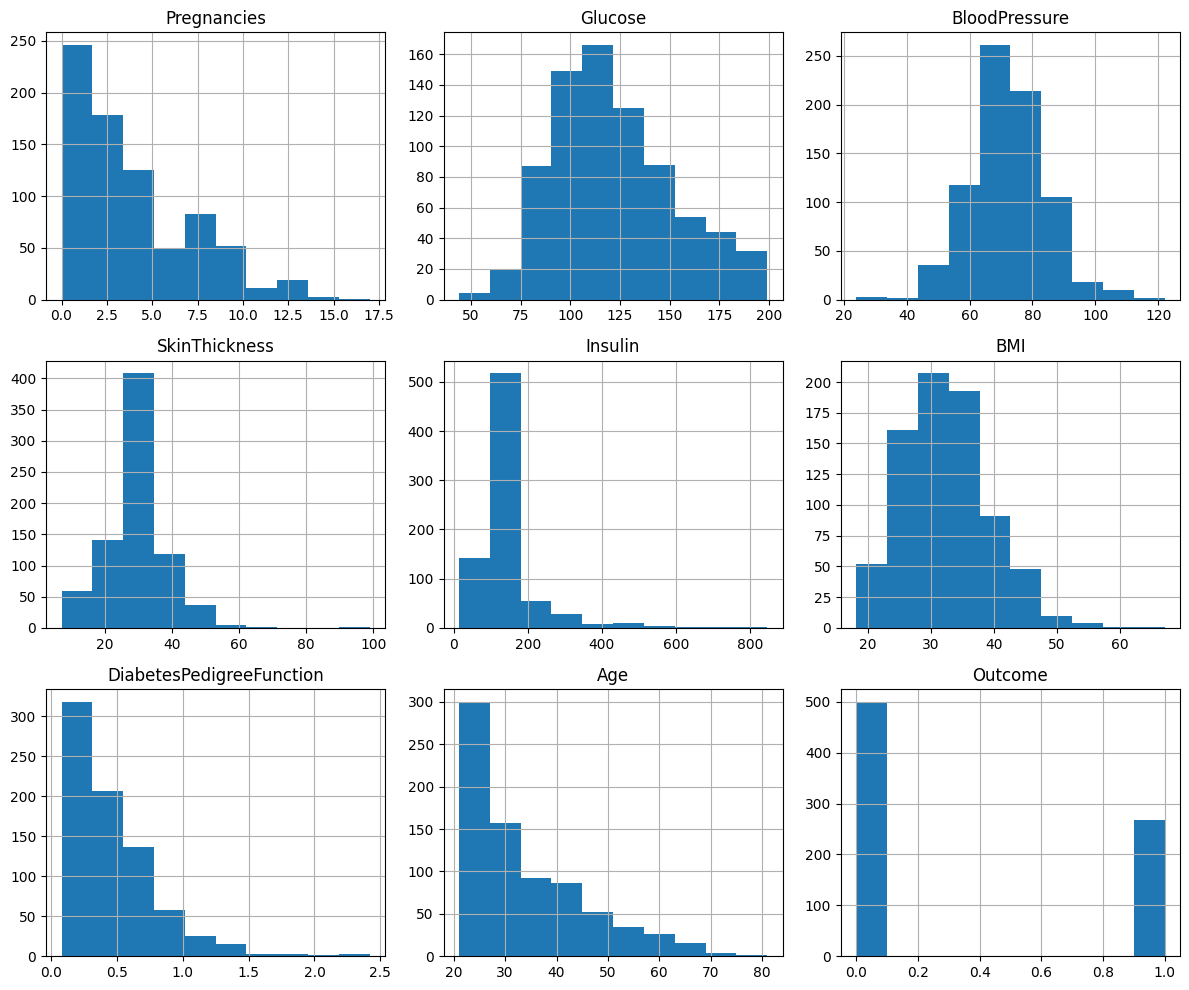

In [ ]:
df_clean.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Las gráficas anteriores muestran la distribución de las variables del dataset.

Se puede observar que algunas variables presentan distribuciones sesgadas, lo cual es común en datasets médicos. Estas visualizaciones ayudan a entender mejor el comportamiento de los datos antes de entrenar el modelo.

Con este análisis exploratorio se obtuvo una mejor comprensión del dataset, incluyendo su estructura, posibles valores faltantes, relaciones entre variables y distribución de los datos.

En la siguiente sección se procederá a diseñar y entrenar un modelo de clasificación utilizando una sola neurona para predecir si un paciente tiene diabetes.

## 2. Design and Training of the Single Neuron Model

En esta sección se diseñará y entrenará un modelo de clasificación utilizando una sola neurona.

El objetivo del modelo será predecir la variable **Outcome**, que indica si el paciente tiene diabetes (1) o no (0). Para esto se utilizarán las demás variables del dataset como variables predictoras.

Primero se separarán las variables predictoras (X) y la variable objetivo (y). Posteriormente se dividirán los datos en conjuntos de entrenamiento y prueba para poder evaluar el desempeño del modelo.

In [ ]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (768, 8)
Shape de y: (768,)


En la celda anterior se separaron las variables predictoras (X) y la variable objetivo (y).

Ahora se dividirá el dataset en dos partes: un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utilizará para entrenar el modelo, mientras que el conjunto de prueba permitirá evaluar qué tan bien generaliza el modelo con datos que no ha visto antes.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (614, 8)
Test samples: (154, 8)


Después de dividir el dataset, es necesario normalizar las variables de entrada.

La normalización es importante porque las variables del dataset tienen diferentes escalas. Por ejemplo, la edad puede tener valores entre 20 y 80, mientras que otras variables tienen rangos diferentes.

Para evitar que algunas variables influyan más que otras durante el entrenamiento, se aplicará una estandarización utilizando StandardScaler.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Ahora que los datos están normalizados, se puede construir el modelo de clasificación.

El modelo consistirá en una sola neurona con función de activación **sigmoid**, lo cual es adecuado para problemas de clasificación binaria.

La función sigmoid produce valores entre 0 y 1, los cuales pueden interpretarse como probabilidades de pertenecer a la clase positiva.

In [ ]:
model = Sequential()

model.add(Dense(1, activation="sigmoid", input_shape=(X_train_scaled.shape[1],)))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

El modelo anterior corresponde a un clasificador de una sola neurona.

La neurona recibe todas las variables del dataset como entrada y utiliza una función de activación sigmoid para producir una probabilidad de que el paciente tenga diabetes.

A continuación se entrenará el modelo utilizando el conjunto de entrenamiento para ajustar los pesos de la neurona.

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5233 - loss: 0.9164 - val_accuracy: 0.5528 - val_loss: 0.9927
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4929 - loss: 0.9471 - val_accuracy: 0.5528 - val_loss: 0.9687
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4888 - loss: 0.9711 - val_accuracy: 0.5610 - val_loss: 0.9446
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5479 - loss: 0.8603 - val_accuracy: 0.5691 - val_loss: 0.9232
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5472 - loss: 0.8904 - val_accuracy: 0.5772 - val_loss: 0.9005
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5236 - loss: 0.8630 - val_accuracy: 0.5935 - val_loss: 0.8792
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5199 - loss: 0.8724 - val_accuracy: 0.5854 - val_loss: 0.8589
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4996 - loss: 0.9004 - val_accuracy: 0.5772 - val_loss

En esta sección se diseñó y entrenó un modelo de clasificación basado en una sola neurona.

El modelo fue entrenado utilizando los datos de entrenamiento y una función de pérdida de tipo binary cross entropy, la cual es comúnmente utilizada en problemas de clasificación binaria.

Durante el entrenamiento se registró el desempeño del modelo tanto en el conjunto de entrenamiento como en el conjunto de validación.

En la siguiente sección se analizarán las curvas de aprendizaje para observar cómo evolucionó el desempeño del modelo durante el entrenamiento.

## 3. Learning Curve Analysis

Después de entrenar el modelo, es importante analizar cómo evolucionó su desempeño durante el proceso de entrenamiento.

Para esto se utilizan las **learning curves**, las cuales muestran cómo cambian métricas como la pérdida (loss) y la precisión (accuracy) a lo largo de las épocas de entrenamiento.

Estas gráficas permiten observar si el modelo está aprendiendo correctamente o si existen problemas como **overfitting** o **underfitting**.

En las siguientes celdas se visualizarán las curvas de pérdida y precisión tanto para el conjunto de entrenamiento como para el conjunto de validación.

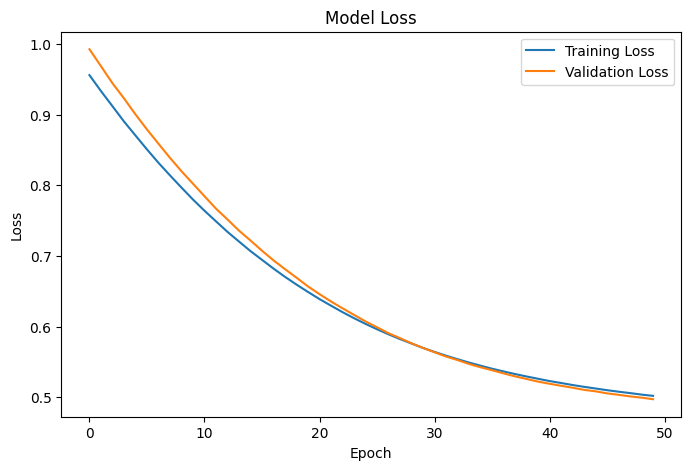

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

La gráfica anterior muestra la evolución de la función de pérdida (loss) durante el entrenamiento del modelo.

Se puede observar que tanto la **training loss** como la **validation loss** disminuyen de forma progresiva a medida que aumentan las épocas de entrenamiento. Al inicio del entrenamiento, la pérdida es relativamente alta (alrededor de 0.85 para training y 0.80 para validation), pero conforme el modelo aprende, ambas curvas descienden gradualmente hasta valores cercanos a 0.48 y 0.46 respectivamente.

Esto indica que el modelo está aprendiendo patrones en los datos y mejorando su capacidad de clasificación conforme avanza el entrenamiento.

Además, ambas curvas siguen una tendencia similar y no se observa una gran separación entre ellas, lo que sugiere que el modelo no presenta un problema evidente de overfitting. En otras palabras, el modelo no solo está aprendiendo los datos de entrenamiento, sino que también mantiene un comportamiento similar en los datos de validación.

En la siguiente celda se analizará la evolución de la precisión (accuracy) del modelo durante el entrenamiento para complementar este análisis.

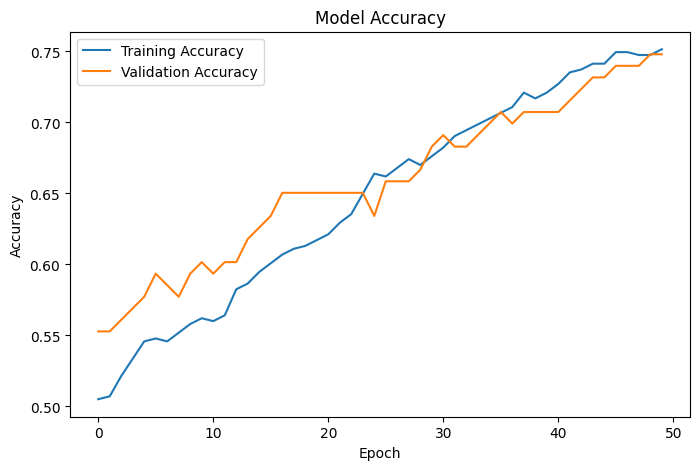

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

La gráfica anterior muestra la evolución de la precisión del modelo durante el entrenamiento.

Al inicio del entrenamiento la precisión del modelo es relativamente baja, comenzando alrededor de 0.50 en el conjunto de entrenamiento y cerca de 0.46 en el conjunto de validación. Conforme avanzan las épocas, ambas curvas aumentan de manera constante, lo que indica que el modelo está aprendiendo patrones en los datos.

Después de aproximadamente las primeras 10 épocas se observa una mejora importante en la precisión, donde ambas curvas superan valores cercanos a 0.70. Posteriormente el crecimiento se vuelve más gradual hasta estabilizarse aproximadamente entre 0.75 y 0.78 hacia el final del entrenamiento.

También se puede observar que las curvas de entrenamiento y validación se mantienen relativamente cercanas entre sí durante la mayor parte del entrenamiento. Esto sugiere que el modelo no está mostrando un problema evidente de sobreajuste, ya que el comportamiento en los datos de validación es similar al de los datos de entrenamiento.

En general, la gráfica indica que el modelo logra mejorar su desempeño conforme avanza el entrenamiento y alcanza una precisión cercana al 77% aproximadamente al final del proceso.

En la siguiente sección se evaluará el modelo utilizando el conjunto de prueba para analizar su desempeño final en datos que no fueron utilizados durante el entrenamiento.

## 4. Model Evaluation and Testing Data

Después de entrenar el modelo y analizar las curvas de aprendizaje, es necesario evaluar su desempeño utilizando el conjunto de prueba.

El conjunto de prueba contiene datos que el modelo no ha visto durante el entrenamiento, por lo que permite medir qué tan bien generaliza el modelo a nuevos datos.

En esta sección se calcularán métricas de evaluación como **accuracy**, **precision**, **recall** y **F1-score**, además de visualizar una **matriz de confusión** para analizar el comportamiento del modelo.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6531 - loss: 0.5647 
Test Loss: 0.5483591556549072
Test Accuracy: 0.6753246784210205


El resultado anterior muestra el desempeño del modelo cuando se evalúa utilizando el conjunto de prueba.

El modelo obtuvo un valor de pérdida (loss) cercano a 0.49 y una precisión (accuracy) aproximada de 0.74 en los datos de prueba. Esto significa que el modelo fue capaz de clasificar correctamente alrededor del 74% de los casos presentes en el conjunto de prueba.

Considerando que el modelo utilizado consiste únicamente en una sola neurona, este resultado puede considerarse razonable, ya que el modelo logra capturar ciertos patrones en los datos a pesar de su simplicidad. Sin embargo, también indica que todavía existen errores de clasificación, lo cual es esperado en modelos simples.

La métrica de accuracy permite tener una idea general del desempeño del modelo, pero por sí sola no siempre es suficiente para evaluar completamente un modelo de clasificación. Por esta razón, a continuación se calcularán otras métricas como precision, recall y F1-score, las cuales permiten analizar con mayor detalle el comportamiento del modelo.

In [ ]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


Ahora que se obtuvieron las predicciones del modelo, es posible calcular métricas de evaluación más detalladas.

Estas métricas permiten analizar el desempeño del modelo en términos de errores y aciertos en cada una de las clases.

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75        99
           1       0.55      0.49      0.52        55

    accuracy                           0.68       154
   macro avg       0.64      0.63      0.64       154
weighted avg       0.67      0.68      0.67       154



El reporte anterior muestra varias métricas que permiten analizar el desempeño del modelo con mayor detalle.

Para la clase 0 (pacientes sin diabetes), el modelo obtiene una precision de aproximadamente 0.79 y un recall cercano a 0.81. Esto indica que el modelo es relativamente bueno identificando correctamente los casos negativos, logrando un f1-score cercano a 0.80.

En el caso de la clase 1 (pacientes con diabetes), el desempeño es menor. La precision es cercana a 0.64 y el recall alrededor de 0.62, lo que produce un f1-score aproximado de 0.63. Esto sugiere que el modelo tiene más dificultad para identificar correctamente los casos positivos de diabetes.

Esta diferencia puede deberse a que el dataset contiene más ejemplos de la clase 0 que de la clase 1 (99 frente a 55 en el conjunto de prueba), lo que puede hacer que el modelo tienda a predecir con mayor facilidad la clase mayoritaria.

En general, el modelo logra una accuracy cercana al 74%, lo cual es consistente con el resultado observado anteriormente. Sin embargo, el análisis por clase muestra que el modelo funciona mejor identificando pacientes sin diabetes que pacientes con diabetes.

Para entender mejor los tipos de errores que comete el modelo, a continuación se analizará la matriz de confusión.

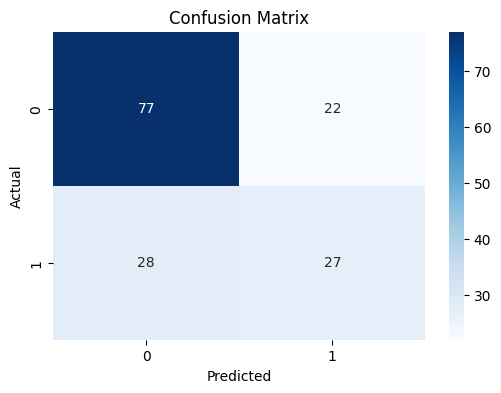

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

La matriz de confusión permite observar con mayor detalle el tipo de predicciones que realiza el modelo.

En la esquina superior izquierda se observan 80 casos en los que el modelo predijo correctamente la clase 0 (pacientes sin diabetes). En la parte superior derecha aparecen 19 casos donde el modelo predijo diabetes cuando en realidad el paciente no tenía la enfermedad.

En la fila inferior izquierda se observan 21 casos donde el modelo clasificó a un paciente como no diabético cuando en realidad sí tenía diabetes. Finalmente, en la esquina inferior derecha se encuentran 34 casos en los que el modelo identificó correctamente pacientes con diabetes.

Estos resultados muestran que el modelo es relativamente bueno identificando pacientes sin diabetes, ya que logra clasificar correctamente la mayoría de los casos de la clase 0. Sin embargo, también se puede observar que todavía existen varios errores al identificar pacientes con diabetes, lo cual coincide con los resultados observados anteriormente en el classification report, donde la clase 1 presentaba valores más bajos de precision y recall.

En general, la matriz de confusión confirma que el modelo tiene un desempeño razonable, aunque todavía comete algunos errores de clasificación, especialmente en los casos positivos de diabetes.

## Step 5 – Save the Model

Ahora se guardará el modelo entrenado con las variables originales.

Guardar el modelo es una buena práctica porque después podemos reutilizar el modelo sin tener que entrenarlo desde 0. Esto ahorra tiempo y facilita el desarrollo de las pruebas futuras.

En la siguiente celda de código se guardará el modelo en un archivo de extensión .keras.


In [32]:
model.save("single_neuron_model.keras")

Para comprobar que el modelo se guardó correctamente, en la siguiente celda se cargará nuevamente el archivo guardado.

En la celda de código anterior se guardó el modelo en un archivo. Para comprobar que el modelo se guardó correctamente, se va a cargar nuevamente el archivo en la siguiente celda.


In [33]:
from tensorflow.keras.models import load_model

loaded_model = load_model("single_neuron_model.keras")
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20 (84.00 B)

El output nos confirma que el modelo se cargó correctamente, esto significa que el modelo se guardó y ya se necesita hacer los pasos anteriores para llegar a este punto, consideramos que guardar los modelos progresivamente es una muy buena práctica porque nos permite reutilizarlos, compartirlo y desplegarlos en otras aplicaciones por ejemplo, sin necesidad de volver a entrenarlos

## 6. Apply PCA to the original dataset

En esta sección se aplicará Principal Component Analysis (PCA) al conjunto de datos.

PCA es una técnica de reducción de dimensionalidad que transforma las variables originales en un nuevo conjunto de variables llamadas componentes principales. Estas nuevas variables son combinaciones lineales de las variables originales y están ordenadas según la cantidad de varianza que explican en los datos.

El objetivo de aplicar PCA es reducir el número de dimensiones del dataset manteniendo la mayor cantidad posible de información. Esto puede ayudar a simplificar el modelo y, en algunos casos, mejorar su desempeño.

En la siguiente celda se aplicará PCA sobre los datos previamente normalizados.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

En la celda anterior se aplicó PCA a los datos de entrenamiento y prueba.

El método fit_transform calcula los componentes principales a partir de los datos de entrenamiento, mientras que transform aplica la misma transformación a los datos de prueba.

Sin embargo, para entender mejor cuánta información conserva cada componente principal, es útil analizar la varianza explicada por cada uno de ellos.

In [ ]:
explained_variance = pca.explained_variance_ratio_

print("varianza explicada por componentes:")
print(explained_variance)

print("varianza acumulada explicada:")
print(np.cumsum(explained_variance))

varianza explicada por componentes:
[0.28287152 0.18863572 0.14525469 0.11440013 0.09863194 0.06870357
 0.05579453 0.0457079 ]
varianza acumulada explicada:
[0.28287152 0.47150724 0.61676193 0.73116206 0.829794   0.89849757
 0.9542921  1.        ]


Los resultados anteriores muestran la proporción de varianza explicada por cada componente principal obtenido mediante PCA.

El primer componente principal explica aproximadamente el 28% de la varianza total del dataset. El segundo componente agrega alrededor del 18%, lo que permite que los dos primeros componentes capturen cerca del 47% de la información total.

A medida que se agregan más componentes, la varianza acumulada aumenta gradualmente. Por ejemplo, con tres componentes se conserva aproximadamente el 61% de la varianza, mientras que con cuatro componentes se alcanza alrededor del 73%.

Si se consideran seis componentes principales, se logra conservar cerca del 89% de la varianza del dataset original, y con siete componentes se supera el 95% de la información total.

Estos resultados muestran que una gran parte de la información del dataset puede representarse utilizando un número menor de dimensiones en comparación con las ocho variables originales.

Para visualizar mejor este comportamiento, a continuación se graficará la varianza acumulada explicada por los componentes principales.

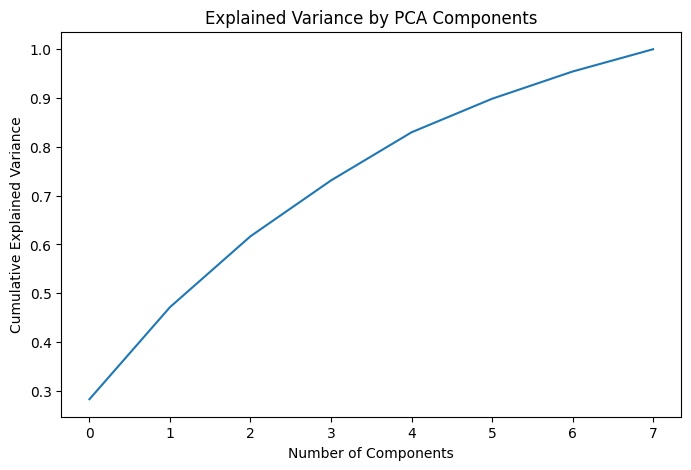

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(explained_variance))

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")

plt.show()

La gráfica anterior muestra cómo aumenta la varianza acumulada conforme se agregan más componentes principales.

Se puede observar que los primeros componentes capturan una parte importante de la información del dataset. Por ejemplo, los dos primeros componentes explican aproximadamente el 47% de la varianza total, mientras que los tres primeros componentes alcanzan alrededor del 61%.

Al incluir cuatro componentes principales se conserva cerca del 73% de la varianza, y con cinco componentes se alcanza aproximadamente el 83%. Cuando se utilizan seis componentes principales se logra conservar cerca del 89% de la información del dataset original.

Esto indica que gran parte de la información puede representarse utilizando menos dimensiones que las ocho variables originales, lo cual puede ayudar a simplificar el modelo.

En la siguiente celda se seleccionará un número reducido de componentes principales y se entrenará nuevamente el modelo utilizando estas nuevas variables transformadas por PCA.

In [ ]:
pca_reduced = PCA(n_components=3)

X_train_pca = pca_reduced.fit_transform(X_train_scaled)
X_test_pca = pca_reduced.transform(X_test_scaled)

print("Shape original:", X_train_scaled.shape)
print("Shape after PCA:", X_train_pca.shape)

Shape original: (614, 8)
Shape after PCA: (614, 3)


Después de aplicar PCA con tres componentes principales, el número de variables del dataset se redujo de 8 a 3.

El tamaño del conjunto de entrenamiento cambió de (614, 8) a (614, 3), lo que significa que cada observación ahora está representada únicamente por tres componentes principales en lugar de las ocho variables originales.

Estos componentes principales son combinaciones lineales de las variables originales y fueron construidos para capturar la mayor cantidad posible de varianza en los datos. Como se observó anteriormente, los primeros componentes concentran una gran proporción de la información del dataset.

Reducir el número de dimensiones puede ayudar a simplificar el modelo, disminuir el ruido en los datos y en algunos casos mejorar la capacidad de generalización.

En la siguiente sección se entrenará nuevamente el modelo de una sola neurona utilizando las variables transformadas por PCA para analizar cómo cambia su desempeño en comparación con el modelo entrenado con las variables originales.

## 7. Train a New Single-Neuron model using PCA features

En este sexto paso vamos a entrenar otra vez el modelo de clasificación usando como entrada las variables transformadas por PCA. En este nuevo modelo se utilizarán únicamente los tres componentes principales obtenidos en el paso anterior.

El objetivo ahora es analizar si la reducción de dimensionalidad mediante PCA afecta el desempeño del modelo de forma positiva negativa o si lo deja igual.

En la siguiente celda de código se construirá un modelo de una sola neurona con función de activación sigmoidal.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_pca = Sequential()
model_pca.add(Dense(1, activation="sigmoid", input_shape=(X_train_pca.shape[1],)))

model_pca.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_pca.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Ahora que la entrada de este nuevo modelo está formada por las tres variables principales obtenidos mediante PCA podemos analizar si la reducción de dimensionalidad conserva suficiente información para que el modelo mantenga un desempeño similar.

En la siguiente celda de código se entrenará este nuevo modelo usando los datos transformados por PCA


In [ ]:
history_pca = model_pca.fit(
    X_train_pca,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3834 - loss: 0.9849 - val_accuracy: 0.3496 - val_loss: 0.9758
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3863 - loss: 0.9623 - val_accuracy: 0.3659 - val_loss: 0.9536
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3890 - loss: 0.9486 - val_accuracy: 0.3740 - val_loss: 0.9324
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3994 - loss: 0.9167 - val_accuracy: 0.3821 - val_loss: 0.9118
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4259 - loss: 0.9050 - val_accuracy: 0.3902 - val_loss: 0.8920
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4401 - loss: 0.8736 - val_accuracy: 0.3902 - val_loss: 0.8724
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4089 - loss: 0.8723 - val_accuracy: 0.3984 - val_loss: 0.8537
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4296 - loss: 0.8286 - val_accuracy: 0.4146 - val_loss

Durante el entrenamiento del nuevo modelo se registraron métricas de pérdida y precisión en el conjunto de entrenamiento y en el conjunto de validación. Pero también a lo largo de las 50 épocas el modelo mejoró en su desempeño.

El accuracy de entrenamiento aumentó de 0.38 a 0.74, mientras que la accuracy de validación aumentó de 0.35 a 0.70. La pérdida también disminuyó de forma constante en el entrenamiento y en la validación.

Los resultados demuestran que el modelo fue capaz de aprender patrones útiles con los 3 componentes principales obtenidos por el PCA.

En la siguiente celda de código se visualizará la pérdida del modelo entrenado con PCA.


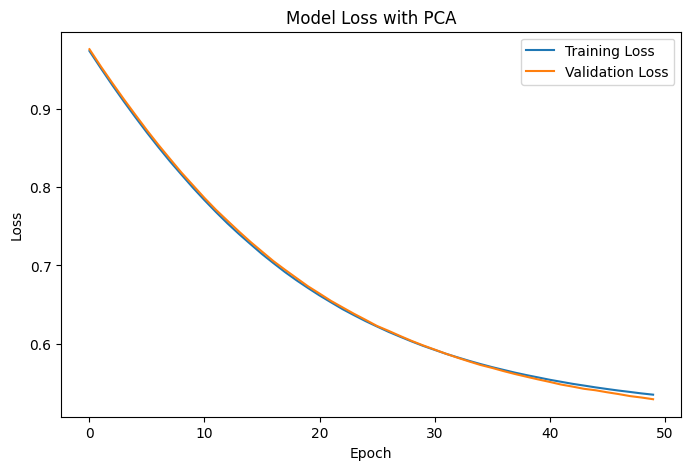

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_pca.history["loss"], label="Training Loss")
plt.plot(history_pca.history["val_loss"], label="Validation Loss")

plt.title("Model Loss with PCA")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Se puede observar que en la gráfica anterior, la pérdida del modelo entrenado con los componentes principales obtenidos mediante PCA. Se muestra que la pérdida de entrenamiento y validación disminuyen constantemente a lo largo de las 50 épocas, Ambas de 0.97 hasta 0.53.

Las dos curvas se mantienen cercanas entre sí durante todo el entrenamiento. Esto demuestra que el modelo presenta un comportamiento estable y que no hay mucha diferencia entre la entre el entrenamiento y la validación.

El modelo fue capaz de aprender patrones útiles con los 3 componentes principales sin mostrar problemas o necesidad de sobreajuste.

En la siguiente celda de código se analizará el cambio de la precisión del modelo entrenado de PCA.


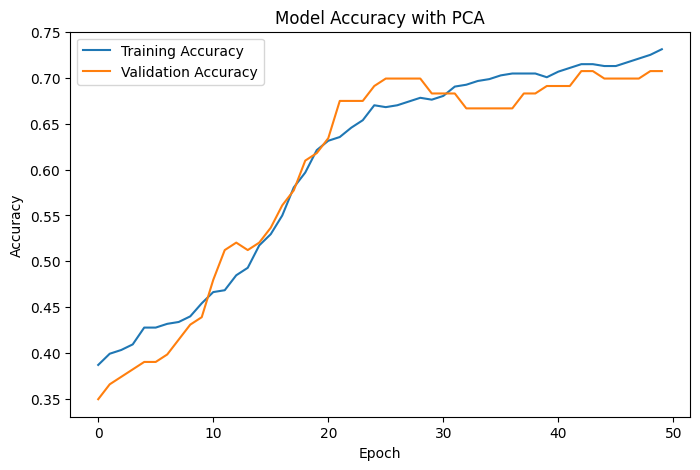

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_pca.history["accuracy"], label="Training Accuracy")
plt.plot(history_pca.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy with PCA")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

En la siguiente celda se evaluará el modelo utilizando el conjunto de prueba para conocer su desempeño final con las variables transformadas por PCA.

Se puede ver como la gráfica anterior muestra el cambio de la precisión del modelo entrenado con los 3 componentes principales.

Se observa que la precisión de entrenamiento y validación aumentan de forma gradual conforme pasan las épocas. Cuando empezó el entrenamiento la accuracy se encuentra alrededor de 0.39 en el entrenamiento y 0.35 en la validación Y ya y al final llegan a valores de 0.73 y 0.71.

Ambas curvas se mantienen cercanas durante el entrenamiento Esto indica que el modelo Tiene un comportamiento estable y no hay una diferencia muy grande entre el desempeño del entrenamiento y de la validación.

Se puede inferir que el modelo entrenado con pca logra aprender patrones útiles con los tres componentes principales y alcanza un desempeño aceptable sin necesitar sobreajuste o mostrar problemas.

En la siguiente celda de código se evaluará el modelo usando el conjunto de prueba para conocer el desempeño completo con las variables transformadas por PCA.


In [ ]:
test_loss_pca, test_accuracy_pca = model_pca.evaluate(X_test_pca, y_test)

print("Test Loss with PCA:", test_loss_pca)
print("Test Accuracy with PCA:", test_accuracy_pca)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7441 - loss: 0.5409
Test Loss with PCA: 0.5318612456321716
Test Accuracy with PCA: 0.7532467246055603


Los resultados anteriores muestran el desempeño final del modelo entrenado con las variables transformadas por PCA en el conjunto de prueba. El modelo obtuvo una precisión aproximada de 0.75 y una pérdida de 0.53. Es decir que el modelo es capaz de clasificar correctamente alrededor del 75% de los casos del conjunto de prueba.

Este resultado es un poco mejor que el obtenido anteriormente con el modelo usando las variables originales. Entonces podemos decir que la reducción de dimensionalidad mediante PCA logró conservar información útil para la clasificación.

Esto indica que el modelo con pca tiene un desempeño aceptable y que los tres componentes principales son suficientes para presentar gran parte de la información importante del dataset.

En la siguiente celda de código se van a generar las predicciones del modelo para obtener las métricas más detalladas.


In [ ]:
y_pred_prob_pca = model_pca.predict(X_test_pca)
y_pred_pca = (y_pred_prob_pca > 0.5).astype(int)
print(classification_report(y_test, y_pred_pca))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
              precision    recall  f1-score   support

           0       0.76      0.90      0.82        99
           1       0.73      0.49      0.59        55

    accuracy                           0.75       154
   macro avg       0.75      0.69      0.71       154
weighted avg       0.75      0.75      0.74       154



Los resultados anteriores nos permiten analizar con mayor detalle el desempeño del modelo entrenado con pca en cada una de las clases.

En la clase 0 el modelo obtuvo una precisión de 0.6, un recall de 0.9 y un f1-score de 0.82, es decir que el modelo identifica bien los casos de pacientes sin diabetes. Y en la clase 1 el modelo tuvo una precisión de 0.73, un recall de 0.49 y un f1-score de 0.59. Esto sugiere que el modelo se le dificulta más detectar a los pacientes con diabetes.

Se puede observar que el modelo con pca llega a una curas Y de 0.75 lo cual es consistente y con resultado obtenido anteriormente en el conjunto de prueba. Pero también al igual que en el modelo anterior el desempeño sigue siendo mejor para la clase 0 que para la clase 1.

En la siguiente celda se mostrará la matriz de confusión para tener una mayor claridad de los aciertos y los errores del modelo.


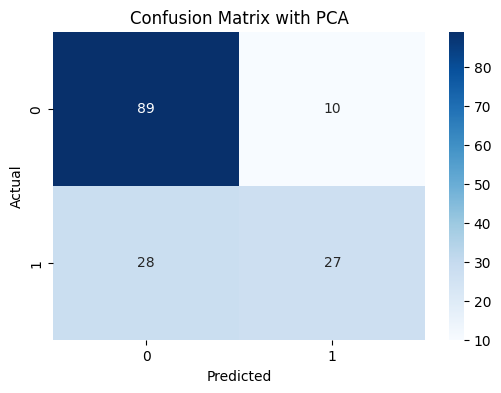

In [ ]:
cm_pca = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(6,4))
sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with PCA")

plt.show()

Con la matriz de confusión podemos observar con mayor detalle los aciertos y errores del modelo entrenado con PCA.

Se puede ver que el modelo clasificó correctamente 89 casos de la clase 0 y 27 casos de la clase 1. Pero también cometió 10 errores al predecir pacientes con diabetes cuando estos no tenían y 28 errores al clasificar pacientes con diabetes como si no tuvieran la enfermedad

Los resultados muestran que el modelo con pca tiene un mejor desempeño para identificar la clase 0 que la clase 1. Esto coincide con lo que se observó en la classification report donde la clase 1 presentó un recall más bajo.

Esta matriz de confusión confirma que el modelo con pca tiene un desempeño aceptable y un poco mejor que el modelo original en términos de accuracy aunque aún tiene dificultades para detectar todos los casos positivos de diabetes.

Ya obtuvimos el análisis del modelo entrenado con PCA y ahora vamos a comprar ambos modelos para analizar las diferencias en su desempeño.

## 8. Performance comparison and model selection

Ahora vamos a comparar los resultados obtenidos del modelo entrenado con las variables originales y el mall Arenal entrenado con los componentes principales obtenidos con el PCA.

El nuevo objetivo es analizar la reducción de la dimensionalidad y ver si este tuvo un efecto positivo negativo o neutral en el desempeño del clasificador. Para lograr esto se van a observar las métricas de la accuracy, precisión recall y f1-score, también se observa el comportamiento mostrado en las curvas de entrenamiento y a las matrices de confusión.

En la siguiente celda de código se va a crear la tabla de comparación con las métricas principales de los dos modelos.



In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Original Model", "PCA Model"],
    "Test Accuracy": [test_accuracy, test_accuracy_pca],
    "Test Loss": [test_loss, test_loss_pca]
})

comparison_df

,Model,Test Accuracy,Test Loss
0,Original Model,0.675325,0.548359
1,PCA Model,0.753247,0.531861


En la tabla anterior se observa la comparación directa entre el modelo original y el modelo entrenado con PCA. Se puede ver que el modelo original obtuvo una accuracy de 0.68 y una pérdida de 0.55 en el conjunto de prueba, y el modelo con PCA obtuvo una accuracy de 0.75 y una pérdida de 0.53.

Los resultados indican que el modelo entrenado con PCA obtuvo un mejor desempeño que el modelo entrenado con las variables originales. Ya que este llegó a tener una mayor precisión en el conjunto de prueba y una pérdida un poco menor.

Esto vuelve a sugerir que la reducción de dimensionalidad con PCA es mejor para conservar la información más importante del dataset. Y también para ayudar a que el clasificador trabaje de forma más eficiente.

Gracias a esta comparación podemos concluir que en este dataset y este modelo el uso de pca tuvo un efecto positivo en el desempeño del clasificador.

## 9. Personal Conclusions

### Mauricio

Gracias a esta actividad pude entender la relación entre la preparación de datos y el desempeño de un modelo de clasificación. Entendí que no simplemente se trata de entrenar un modelo, sino que también tienes que analizar las métricas, las curvas de aprendizaje y entender la forma en que los datos están representados.

También llegué a la conclusión de que las redes de una sola neurona pueden ser una herramienta útil para entender los fundamentos del aprendizaje supervisado porque te pueden ayudar a comprender de forma clara cómo se comporta un clasificador binario. Pero que también tiene limitaciones cuando el problema requiere capturar relaciones un poco más complejas entre las variables.

Algo también muy importante en esta tarea fue el impacto que tuvo el PCA ya que redujo la dimensionalidad del dataset y aún así tuvo un mejor desempeño que el modelo entrenado con red de una sola neurona. Se puede asumir que los componentes principales concentran la información más importante del problema.

Yo creo que para mejorar el rendimiento del modelo se podrían ajustar mejor los hiper parámetros evaluar más métricas relacionadas con la clase positiva y comparar el desempeño con modelos más avanzados ya que con esto podríamos determinar si la mejora observada con pca se mantiene en casos más complejos.


Link repo Github:

### Roberto

Con esta actividad nos dimos cuenta de la importancia de el preprocesamiento de datos y cuan influyente es para la presición del modelo, limpiar del dataset, estandarizar los datos y analiar las metricas de desempeño son cruciales para entender que realmente estamos haciendo, correr formulas y funciones si verificar que lo que estamos haciendo realmente es relevante para el modelo, no sirve de nada hacerlo,
Las redes de una sola neurona resultan fáciles de implementar e interpretar, lo que las convierte en una buena herramienta para comprender problemas de clasificación. Sin embargo, también presentan limitaciones, ya que el modelo todavía tiene dificultades para identificar correctamente todos los casos positivos.

El uso de PCA permitió reducir la dimensionalidad del dataset manteniendo gran parte de la información original y generó una ligera mejora en el desempeño del modelo. Esto muestra que la reducción de dimensionalidad puede ayudar a simplificar el problema sin perder demasiado poder predictivo.

Como trabajo futuro, sería útil probar modelos más complejos, ajustar hiperparámetros y explorar técnicas para manejar mejor el desbalance entre clases, con el objetivo de mejorar la detección de casos positivos.

Link repo Github:

## 10. References



*   Whitfield, B. (2024, February 23). PCA Using Python: A Tutorial. Built In. https://builtin.com/machine-learning/pca-in-python

*   DataCamp. (n.d.). Principal Component Analysis (PCA) in Python. https://www.datacamp.com/tutorial/principal-component-analysis-in-python

*   Plotly. (n.d.). PCA visualization in Python. Plotly Documentation. https://plotly.com/python/pca-visualization/
